In [1]:
import pandas as pd, numpy as np

PATH = "data_without_straw.xlsx"          # adjust if needed
df   = pd.read_excel(PATH)

req = ["Participant_ID", "Time", "Label", "Actual_Volume"]
print("Columns in file:\n", df.columns.tolist(), "\n")
for col in req:
    assert col in df.columns, f"Missing column: {col}"

print("---- Quick stats ------------------------------------------------")
print("Rows                    :", len(df))
print("Participants            :", df['Participant_ID'].nunique())
print("Frames flagged drinking :", (df["Label"]==1).sum())
print("Any NaN in ActualVolume :", df['Actual_Volume'].isna().any())
print(df[['Actual_Volume']].describe())

Columns in file:
 ['Time', 'Zone_0', 'Zone_1', 'Zone_2', 'Zone_3', 'Zone_4', 'Zone_5', 'Zone_6', 'Zone_7', 'Zone_8', 'Zone_9', 'Zone_10', 'Zone_11', 'Zone_12', 'Zone_13', 'Zone_14', 'Zone_15', 'Zone_16', 'Zone_17', 'Zone_18', 'Zone_19', 'Zone_20', 'Zone_21', 'Zone_22', 'Zone_23', 'Zone_24', 'Zone_25', 'Zone_26', 'Zone_27', 'Zone_28', 'Zone_29', 'Zone_30', 'Zone_31', 'Zone_32', 'Zone_33', 'Zone_34', 'Zone_35', 'Zone_36', 'Zone_37', 'Zone_38', 'Zone_39', 'Zone_40', 'Zone_41', 'Zone_42', 'Zone_43', 'Zone_44', 'Zone_45', 'Zone_46', 'Zone_47', 'Zone_48', 'Zone_49', 'Zone_50', 'Zone_51', 'Zone_52', 'Zone_53', 'Zone_54', 'Zone_55', 'Zone_56', 'Zone_57', 'Zone_58', 'Zone_59', 'Zone_60', 'Zone_61', 'Zone_62', 'Zone_63', 'Label', 'Volume', 'Participant_ID', 'Actual_Volume', 'Straw', 'Gender', 'Container_Weight', 'drink', 'temp'] 

---- Quick stats ------------------------------------------------
Rows                    : 80075
Participants            : 39
Frames flagged drinking : 0
Any NaN in A

In [2]:
# # Option-1  tell Keras *not* to rebuild the loss/metrics when loading
# regr = tf.keras.models.load_model("sip_volume_regressor.h5", compile=False)

# # if you later want to call evaluate()/fit(), just compile again
# regr.compile(optimizer="adam", loss="mse", metrics=["mae"])

In [3]:
import pandas as pd, numpy as np, tensorflow as tf
from tensorflow.keras import layers, models

# ────────────────────────────────────────────────────────────────
# 0. FILE & COLUMN NAMES
# ────────────────────────────────────────────────────────────────
PATH        = "data_without_straw.xlsx"
id_col      = "Participant_ID"
time_col    = "Time"
flag_col    = "Label"           # 'Drinking' / 'Not_Drinking'
vol_col     = "Actual_Volume"

# ────────────────────────────────────────────────────────────────
# 1. LOAD  +  MAP LABEL -> 0/1
# ────────────────────────────────────────────────────────────────
df = (pd.read_excel(PATH)
        .sort_values([id_col, time_col])
        .reset_index(drop=True))

df[flag_col] = df[flag_col].map({"Drinking": 1, "Not_Drinking": 0})
assert df[flag_col].isin([0, 1]).all(), "Label still not 0/1"

# ────────────────────────────────────────────────────────────────
# 2. FIND SIP BOUNDARIES
# ────────────────────────────────────────────────────────────────
df["prev"] = df.groupby(id_col)[flag_col].shift(fill_value=0)
df["next"] = df.groupby(id_col)[flag_col].shift(-1, fill_value=0)

df["sip_start"] = (df["prev"] == 0) & (df[flag_col] == 1)        # first Drinking frame
df["sip_end"]   = (df[flag_col] == 1) & (df["next"] == 0)        # last Drinking frame
df["sip_id"]    = df.groupby(id_col)["sip_start"].cumsum()       # 1,2,3,…

# rows where sip_start / sip_end are True
starts = df.loc[df["sip_start"]]
ends   = df.loc[df["sip_end"]]

# ────────────────────────────────────────────────────────────────
# 3.  PICK VOLUME BEFORE-START  &  AFTER-END
#     (guard against boundary rows)
# ────────────────────────────────────────────────────────────────
vol_before = (df.loc[starts.index - 1, vol_col]          # prev row
                .reset_index(drop=True)
                .rename("vol_before"))
vol_after  = (df.loc[ends.index + 1, vol_col]            # next row
                .reset_index(drop=True)
                .rename("vol_after"))

sip_delta = (pd.concat([starts[[id_col, "sip_id"]].reset_index(drop=True),
                        vol_before,
                        vol_after], axis=1)
               .dropna(subset=["vol_before", "vol_after"]))   # drop edges

sip_delta["dV"] = sip_delta["vol_before"] - sip_delta["vol_after"]
print("Non-zero ΔV rows:", (sip_delta["dV"] != 0).sum(), "/", len(sip_delta))
print(sip_delta["dV"].describe())

assert (sip_delta["dV"] != 0).any(), "ΔV still zero – check volume logging!"

# attach dV to every Drinking frame so we can build sequences
df = df.merge(sip_delta[[id_col, "sip_id", "dV"]],
              on=[id_col, "sip_id"], how="left")

# ────────────────────────────────────────────────────────────────
# 4.  BUILD SIP-LEVEL TENSORS
# ────────────────────────────────────────────────────────────────
sensor_cols = [c for c in df.columns if c.startswith("Zone_")]
MAXLEN, PAD = 120, 0.0
X_list, y_list = [], []

for (_, sid), sub in df[df[flag_col]==1].groupby([id_col, "sip_id"]):
    if sub["dV"].isna().all():               # skip sips without ΔV
        continue
    seq = sub[sensor_cols].to_numpy("float32")
    seq = seq[:MAXLEN] if len(seq) > MAXLEN else \
          np.vstack([seq,
                     np.full((MAXLEN-len(seq), seq.shape[1]), PAD, "float32")])
    X_list.append(seq)
    y_list.append(sub["dV"].iloc[0])

X = np.stack(X_list)
y = np.asarray(y_list, "float32")
print("Shapes  X:", X.shape, "  y:", y.shape)

# ────────────────────────────────────────────────────────────────
# 5.  TRAIN (FIRST TIME ONLY)  OR  JUST LOAD
# ────────────────────────────────────────────────────────────────
if not tf.io.gfile.exists("sip_volume_regressor.keras"):
    inp = layers.Input(shape=(MAXLEN, X.shape[2]))
    x = layers.Masking(PAD)(inp)
    x = layers.Conv1D(64, 5, activation="relu", padding="same")(x)
    x = layers.MaxPool1D(2)(x)
    x = layers.Bidirectional(layers.LSTM(64))(x)
    out = layers.Dense(1)(x)
    regr = models.Model(inp, out)
    regr.compile(optimizer="adam", loss="mse", metrics=["mae"])
    regr.fit(X, y, epochs=20, batch_size=128, validation_split=0.1,
             callbacks=[tf.keras.callbacks.EarlyStopping(patience=3,
                                                         restore_best_weights=True)])
    regr.save("sip_volume_regressor.keras")
else:
    regr = tf.keras.models.load_model("sip_volume_regressor.keras",
                                      compile=False)     # ◀ no 'mse' error
    regr.compile(optimizer="adam", loss="mse", metrics=["mae"])

# ────────────────────────────────────────────────────────────────
# 6.  LOAD YOUR CLASSIFIER (ALREADY TRAINED)
# ────────────────────────────────────────────────────────────────
clf = tf.keras.models.load_model("Best_gesture_recognition_model.h5")

print("Two-stage system ready →  clf (gesture) + regr (sip volume)")

Non-zero ΔV rows: 312 / 316
count    316.000000
mean      29.015881
std       23.513118
min        0.000000
25%       13.663075
50%       22.959354
75%       35.600000
max      160.200000
Name: dV, dtype: float64
Shapes  X: (316, 120, 64)   y: (316,)


/opt/anaconda3/envs/ACM1/lib/python3.12/site-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'conv1d_1' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Two-stage system ready →  clf (gesture) + regr (sip volume)


In [4]:
df[flag_col]

0        0
1        0
2        0
3        0
4        0
        ..
80070    0
80071    0
80072    0
80073    0
80074    0
Name: Label, Length: 80075, dtype: int64

In [5]:
import numpy as np
import pandas as pd
import tensorflow as tf

# ----------------------------------------------------------
# PARAMETERS – keep in one place for easy tweaking
# ----------------------------------------------------------
SENSOR_COLS = [f"Zone_{i}" for i in range(64)]   # what goes to the CNN-LSTM
MAXLEN      = 120
PAD_VALUE   = 0.0
LABEL_MAP   = {"Drinking": 1, "Not_Drinking": 0}
THRESH      = 0.5       # classifier output > THRESH ⇒ 'Drinking'

def frame_classify(df, clf):
    """
    Run the gesture-classifier on every frame and attach a binary flag column
    'pred_flag' (1 = drinking, 0 = not).
    """
    x_frames = df[SENSOR_COLS].to_numpy("float32")
    probs    = clf.predict(x_frames, verbose=0).squeeze()   # (n_frames,)
    df["pred_flag"] = (probs > THRESH).astype(int)
    return df

def find_sip_boundaries(df, flag_col="pred_flag", id_col="Participant_ID"):
    """
    Detect 0→1 (start) and 1→0 (end) transitions in the predicted flag,
    create sip_id, and return a dataframe with only drinking frames.
    """
    df = df.copy()
    df["prev"] = df.groupby(id_col)[flag_col].shift(fill_value=0)
    df["next"] = df.groupby(id_col)[flag_col].shift(-1, fill_value=0)

    df["sip_start"] = (df["prev"] == 0) & (df[flag_col] == 1)
    df["sip_id"]    = df.groupby(id_col)["sip_start"].cumsum()
    return df[df[flag_col] == 1]   # keep only frames inside predicted sips

def sip_tensor(seq):
    """
    Crop / pad one sip to MAXLEN frames and return the tensor.
    """
    if len(seq) > MAXLEN:
        seq = seq[:MAXLEN]
    elif len(seq) < MAXLEN:
        pad = np.full((MAXLEN-len(seq), seq.shape[1]), PAD_VALUE, "float32")
        seq = np.vstack([seq, pad])
    return seq.astype("float32")

def predict_sip_volumes(sip_frames, regr):
    """
    Given a dataframe with ONLY drinking frames and column 'sip_id',
    build one tensor per sip, run the regressor, and return a table
    (Participant_ID, sip_id, predicted_dV).
    """
    tensors, keys = [], []
    for (pid, sid), sub in sip_frames.groupby(["Participant_ID", "sip_id"]):
        tensors.append(sip_tensor(sub[SENSOR_COLS].values))
        keys.append((pid, sid))
    X = np.stack(tensors)
    preds = regr.predict(X, verbose=0).squeeze()
    out = pd.DataFrame(keys, columns=["Participant_ID", "sip_id"])
    out["predicted_dV"] = preds
    return out

In [6]:
X

array([[[2487.,  165.,  348., ...,  364.,  330., 1817.],
        [2487.,  165.,  348., ...,  364.,  330., 1817.],
        [ 265.,  200.,  234., ...,  364.,  352., 1817.],
        ...,
        [   0.,    0.,    0., ...,    0.,    0.,    0.],
        [   0.,    0.,    0., ...,    0.,    0.,    0.],
        [   0.,    0.,    0., ...,    0.,    0.,    0.]],

       [[ 337., 2224., 2696., ...,  409., 1969., 1374.],
        [ 337., 2224., 2696., ...,  409., 1969., 1374.],
        [ 337., 2224., 2696., ...,  409., 1969., 1515.],
        ...,
        [   0.,    0.,    0., ...,    0.,    0.,    0.],
        [   0.,    0.,    0., ...,    0.,    0.,    0.],
        [   0.,    0.,    0., ...,    0.,    0.,    0.]],

       [[2147., 2502., 2374., ...,  323.,  335., 1309.],
        [2147., 2502., 2374., ...,  323.,  335., 1309.],
        [ 256.,  276.,  236., ...,  320.,  332., 1309.],
        ...,
        [   0.,    0.,    0., ...,    0.,    0.,    0.],
        [   0.,    0.,    0., ...,    0.,    

In [7]:
y

array([ 69.90476  ,  58.       ,  61.904762 ,  68.85714  ,  44.57143  ,
        27.904762 ,  11.5079365,  14.186508 ,  12.5      ,  12.5      ,
        11.111111 ,  19.642857 ,  16.964285 ,  15.047619 ,  22.095238 ,
        20.47619  ,   9.142858 ,  10.476191 ,   8.380953 ,   2.6444662,
         3.9177277,   1.7629775,   3.4280117,   2.1547503,   5.582762 ,
         1.6650343,   2.9382958,   9.027778 ,  20.337301 ,  18.75     ,
        39.781746 ,  12.996032 ,   6.6468253,  22.519842 ,  21.825397 ,
        26.052889 ,  20.372185 ,  20.666014 ,  19.392752 ,  20.176298 ,
        21.547503 ,  21.547503 ,  20.470127 ,  21.841331 ,  20.27424  ,
        18.511263 ,  14.201763 ,  87.8      ,  53.2      ,  43.8      ,
        39.1      ,  36.3      ,  33.8      ,  54.3      ,  58.7      ,
        58.7      ,  40.       ,   9.486166 ,  14.130435 ,  14.229249 ,
        14.624506 ,  14.624506 ,  15.118577 ,  15.513834 ,  12.747036 ,
        10.770751 ,  10.474308 ,  11.561265 ,  12.549407 ,   9.6

In [8]:
# RAW_FILE = "new_session.xlsx"       # a recording that has never been seen
# df_raw   = pd.read_excel(RAW_FILE)

# # 1)  Per-frame gesture classification
# df_raw = frame_classify(df_raw, clf)

# # 2)  Segment the predicted drinking windows
# sip_frames = find_sip_boundaries(df_raw, flag_col="pred_flag")

# # 3)  Predict Δ-volume for each sip
# sip_pred = predict_sip_volumes(sip_frames, regr)

# print(sip_pred.head())
# #   Participant_ID  sip_id  predicted_dV
# # 0            102       1        27.854
# # 1            102       2        23.121
# # ...

# # 4)  Optional – cumulative consumption per participant
# summary = (sip_pred.groupby("Participant_ID")["predicted_dV"]
#                     .sum()
#                     .rename("total_consumed_ml"))
# print(summary)

In [9]:
# import numpy as np
# import pandas as pd
# import tensorflow as tf

# # ----------------------------------------------------------
# # PARAMETERS – keep in one place for easy tweaking
# # ----------------------------------------------------------
# SENSOR_COLS = [f"Zone_{i}" for i in range(64)]   # what goes to the CNN-LSTM
# MAXLEN      = 120
# PAD_VALUE   = 0.0
# LABEL_MAP   = {"Drinking": 1, "Not_Drinking": 0}
# THRESH      = 0.5       # classifier output > THRESH ⇒ 'Drinking'

# def frame_classify(df, clf):
#     """
#     Run the gesture-classifier on every frame and attach a binary flag column
#     'pred_flag' (1 = drinking, 0 = not).
#     """
#     x_frames = df[SENSOR_COLS].to_numpy("float32")
#     probs    = clf.predict(x_frames, verbose=0).squeeze()   # (n_frames,)
#     df["pred_flag"] = (probs > THRESH).astype(int)
#     return df

# def find_sip_boundaries(df, flag_col="pred_flag", id_col="Participant_ID"):
#     """
#     Detect 0→1 (start) and 1→0 (end) transitions in the predicted flag,
#     create sip_id, and return a dataframe with only drinking frames.
#     """
#     df = df.copy()
#     df["prev"] = df.groupby(id_col)[flag_col].shift(fill_value=0)
#     df["next"] = df.groupby(id_col)[flag_col].shift(-1, fill_value=0)

#     df["sip_start"] = (df["prev"] == 0) & (df[flag_col] == 1)
#     df["sip_id"]    = df.groupby(id_col)["sip_start"].cumsum()
#     return df[df[flag_col] == 1]   # keep only frames inside predicted sips

# def sip_tensor(seq):
#     """
#     Crop / pad one sip to MAXLEN frames and return the tensor.
#     """
#     if len(seq) > MAXLEN:
#         seq = seq[:MAXLEN]
#     elif len(seq) < MAXLEN:
#         pad = np.full((MAXLEN-len(seq), seq.shape[1]), PAD_VALUE, "float32")
#         seq = np.vstack([seq, pad])
#     return seq.astype("float32")

# def predict_sip_volumes(sip_frames, regr):
#     """
#     Given a dataframe with ONLY drinking frames and column 'sip_id',
#     build one tensor per sip, run the regressor, and return a table
#     (Participant_ID, sip_id, predicted_dV).
#     """
#     tensors, keys = [], []
#     for (pid, sid), sub in sip_frames.groupby(["Participant_ID", "sip_id"]):
#         tensors.append(sip_tensor(sub[SENSOR_COLS].values))
#         keys.append((pid, sid))
#     X = np.stack(tensors)
#     preds = regr.predict(X, verbose=0).squeeze()
#     out = pd.DataFrame(keys, columns=["Participant_ID", "sip_id"])
#     out["predicted_dV"] = preds
#     return out

In [10]:
sip_rows = df[df['Label'] == 1].copy()
X_list, y_list, id_list = [], [], []
MAXLEN = 120
PADVAL = 0.0

for (pid, sid), sub in sip_rows.groupby(["Participant_ID", "sip_id"]):
    seq = sub[sensor_cols].to_numpy(dtype="float32")
    if len(seq) >= MAXLEN:
        seq = seq[:MAXLEN]
    else:
        pad = np.full((MAXLEN-len(seq), seq.shape[1]), PADVAL, dtype="float32")
        seq = np.vstack([seq, pad])
    X_list.append(seq)
    y_list.append(sub["dV"].iloc[0])
    id_list.append(pid)

X = np.stack(X_list)
y = np.asarray(y_list, dtype="float32")
pid_codes, _ = pd.factorize(id_list)

/var/folders/s7/ddngkscs167c_65wscck142m0000gr/T/ipykernel_67041/2740276047.py:19: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  pid_codes, _ = pd.factorize(id_list)


In [11]:
# sip_rows = sip_rows.merge(delta[[id_col,"sip_id","dV"]],
#                           on=[id_col,"sip_id"],
#                           how="left")

In [12]:
# sensor_cols = [c for c in sip_rows.columns
#                if c.startswith(("ax_","gy_","twf_"))]   # adapt list!
# assert sensor_cols, "sensor_cols turned out empty – wrong prefixes?"

# MAXLEN = 120
# X_list, y_list, id_list = [], [], []
# PADVAL = 0.0

# for (pid, sid), sub in sip_rows.groupby([id_col,"sip_id"]):
#     seq = sub[sensor_cols].to_numpy(dtype="float32")
#     if len(seq) == 0:          # should never happen
#         continue
#     # crop / pad
#     if len(seq) > MAXLEN:
#         seq = seq[:MAXLEN]
#     elif len(seq) < MAXLEN:
#         pad = np.full((MAXLEN-len(seq), seq.shape[1]), PADVAL, dtype="float32")
#         seq = np.vstack([seq, pad])

#     X_list.append(seq)
#     y_list.append(sub["dV"].iloc[0])
#     id_list.append(pid)

# if not X_list:
#     raise ValueError("No sip sequences survived – check the previous steps.")

# X   = np.stack(X_list)                 # (n_sips, MAXLEN, n_feat)
# y   = np.asarray(y_list, dtype="float32")
# pid_codes, _ = pd.factorize(id_list)   # encoder for participant ID

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


In [14]:
print("X shape:", X.shape)          # Should have same number of samples as y and pid_codes
print("y shape:", y.shape)
print("pid_codes length:", len(pid_codes))
# # unique_participants = df['Participant_ID'].unique()
# # pid_codes = pd.Series(range(len(unique_participants)), index=unique_participants)
# # Extract the unique participant IDs
# unique_participants = df['Participant_ID'].unique()

# # Create a mapping of participant IDs to numeric PIDs from 0 to 315
# pid_mapping = {participant: idx for idx, participant in enumerate(unique_participants)}

# pid_codes = df['Participant_ID'].map(pid_mapping).values

X shape: (316, 120, 64)
y shape: (316,)
pid_codes length: 316


In [15]:
# ------------------------------------------------------------
# 0  PRE-REQUISITES
#     X : (n_sips, 120, 64)  tensors
#     y : (n_sips,)          ground-truth ΔV  [ml]
#     pid_codes : (n_sips,)  participant ids already factorised
# ------------------------------------------------------------
import numpy as np, pandas as pd, tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras import layers, models
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import random, os
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import layers, models, optimizers, regularizers
# reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

MAXLEN, NFEAT, PAD = X.shape[1], X.shape[2], 0.0

# ------------------------------------------------------------
# 1  TRAIN / TEST SPLIT   (grouped by participant)
# ------------------------------------------------------------
gss = GroupShuffleSplit(test_size=0.10, n_splits=1, random_state=SEED)
train_idx, test_idx = next(gss.split(X, y, groups=pid_codes))

X_train, y_train = X[train_idx], y[train_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)
print(f"Train sips: {len(train_idx)}   Test sips: {len(test_idx)}")
print("Participants in train :", np.unique(pid_codes[train_idx]).size)
print("Participants in test  :", np.unique(pid_codes[test_idx]).size)

# ------------------------------------------------------------
# 2  BUILD REGRESSION MODEL
# ------------------------------------------------------------
# def build_regressor(maxlen=MAXLEN, nfeat=NFEAT, pad=PAD):
#     inp = layers.Input(shape=(maxlen, nfeat))
#     x   = layers.Masking(mask_value=pad)(inp)         # keeps padding invisible
#     x   = layers.Conv1D(64, 5, activation="relu", padding="same")(x)
#     x   = layers.MaxPool1D(2)(x)
#     x   = layers.Bidirectional(layers.LSTM(64))(x)
#     out = layers.Dense(1)(x)
#     model = models.Model(inp, out)
#     model.compile(optimizer="adam", loss="mse", metrics=["mae"])
#     return model


 
   
# Build and summarize the model
def build_regressor(maxlen=120, nfeat=64, pad=0):
    # Define input layer
    inp = layers.Input(shape=(maxlen, nfeat))
    
    # Masking to ignore padding values
    x = layers.Masking(mask_value=pad)(inp)

    # First Convolutional layer
    x = layers.Conv1D(128, 3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # Second Convolutional layer
    x = layers.Conv1D(128, 5, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # Third Convolutional layer
    x = layers.Conv1D(256, 3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # Fourth Convolutional layer
    x = layers.Conv1D(256, 5, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # Fifth Convolutional layer
    x = layers.Conv1D(512, 3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # First GRU layer
    x = layers.Bidirectional(layers.GRU(128, return_sequences=True))(x)
    x = layers.Dropout(0.9)(x)

    # Second GRU layer
    gru_out = layers.Bidirectional(layers.GRU(64, return_sequences=True))(x)

    # Dimensionality adjustment for skip connection
    x_skip = layers.Bidirectional(layers.GRU(64, return_sequences=True))(x)

    # Perform the skip connection
    x = layers.Add()([x_skip, gru_out])  # Adding skip connection
    x = layers.Activation('relu')(x)

    # Continue processing
    x = layers.Dropout(0.9)(x)

    # Final GRU layer
    x = layers.Bidirectional(layers.GRU(32))(x)
    x = layers.Dropout(0.9)(x)

    # Process with output layers
    x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(0.01))(x)  # Improved dense layer
    x = layers.Dropout(0.9)(x)  # Dropout before output
    out = layers.Dense(1)(x)  # Final output layer

    # Create and compile the model
    model = models.Model(inp, out)
    model.compile(optimizer=optimizers.Adam(learning_rate=0.001), loss="mse", metrics=["mae"])
    
    return model

model = build_regressor(maxlen=120, nfeat=64, pad=0)
model.summary()
# ------------------------------------------------------------
# 3  TRAIN
# ------------------------------------------------------------
# callbacks = [tf.keras.callbacks.EarlyStopping(patience=5,
#                                               restore_best_weights=True)]
# history = regr.fit(X_train, y_train,
#                    epochs=60,
#                    batch_size=32,
#                    validation_split=0.1,
#                    callbacks=callbacks,
#                    verbose=1)
early_stopping = EarlyStopping(monitor='mae', patience=2, restore_best_weights=True)

# Assuming X_train, y_train, X_val, and y_val are defined:
history = model.fit(X_train, y_train,  
                    epochs=3, 
                    batch_size=2,  # Adjust as necessary
                    callbacks=[early_stopping])
# ------------------------------------------------------------
# 4  EVALUATE
# ------------------------------------------------------------
y_pred = regr.predict(X_test).squeeze()

mse  = mean_squared_error(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
rmspe = np.sqrt(mse) / y_test.mean()

print("\n─────────  Test metrics  ─────────")
print(f"MSE  : {mse:8.3f}  (ml²)")
print(f"RMSE : {np.sqrt(mse):8.3f}  (ml)")
print(f"MAE  : {mae:8.3f}  (ml)")
print(f"R²   : {r2:8.3f}")
print(f"RMSPE {100*np.mean(rmspe):.2f}%")
# optional: quick look at first 10 predictions
pd.DataFrame({"y_true": y_test[:100],
              "y_pred": y_pred[:100]}).round(2)

Train sips: 294   Test sips: 22
Participants in train : 35
Participants in test  : 4


/opt/anaconda3/envs/ACM1/lib/python3.12/site-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 120, 64)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 120, 64)   │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 120, 128)  │     24,704 │ masking[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 120, 128)  │        512 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 60, 128)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 60, 128)   │     82,048 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 128)   │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 30, 128)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 30, 256)   │     98,560 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 256)   │      1,024 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 15, 256)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 15, 256)   │    327,936 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 256)   │      1,024 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 7, 256)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 7, 512)    │    393,728 │ max_pooling1d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 512)    │      2,048 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_4     │ (None, 3, 512)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 3, 256)    │    493,056 │ max_pooling1d_4[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 3, 256)    │          0 │ bidirectional[0]

 Total params: 1,712,001 (6.53 MB)

 Trainable params: 1,709,441 (6.52 MB)

 Non-trainable params: 2,560 (10.00 KB)

Epoch 1/3
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 1474.1415 - mae: 29.0099
Epoch 2/3
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1316.5266 - mae: 26.3586
Epoch 3/3
147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1144.7650 - mae: 23.2260
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step

─────────  Test metrics  ─────────
MSE  : 1293.234  (ml²)
RMSE :   35.962  (ml)
MAE  :   28.995  (ml)
R²   :   -1.338
RMSPE 83.09%


/opt/anaconda3/envs/ACM1/lib/python3.12/site-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'conv1d_1' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


,y_true,y_pred
0,9.030000,16.290001
1,20.340000,16.040001
2,18.750000,16.139999
3,39.779999,16.230000
4,13.000000,16.270000
5,6.650000,16.110001
6,22.520000,16.080000
7,21.830000,16.170000
8,70.480003,15.790000
9,45.810001,16.150000


            Time  Zone_0  Zone_1  Zone_2  Zone_3  Zone_4  Zone_5  Zone_6  \
0  1747823631000    2162    2155    3941     362     324     342    3605   
1  1747823631200    2162    2155    3941     362     324     342    3605   
2  1747823631400    2162    2155    3941     362     324     342    3605   
3  1747823631600    2162    2155    3941     362     324     342    3605   
4  1747823631800    2162    2155    3941     362     324     342    3605   

   Zone_7  Zone_8  ...  Gender  Container_Weight   drink  temp  prev  next  \
0    2071    2121  ...    Male              19.8  coke-r     c     0     0   
1    2071    2121  ...    Male              19.8  coke-r     c     0     0   
2    2071    2121  ...    Male              19.8  coke-r     c     0     0   
3    2071    2121  ...    Male              19.8  coke-r     c     0     0   
4    2071    2121  ...    Male              19.8  coke-r     c     0     0   

   sip_start  sip_end  sip_id  dV  
0      False    False       0 NaN  
1 

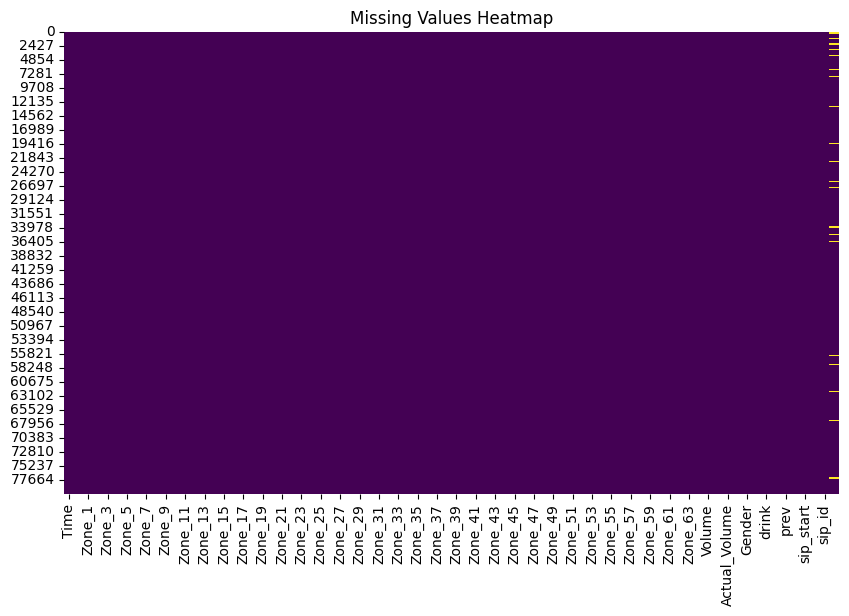

ValueError: num must be an integer with 1 <= num <= 16, not 17

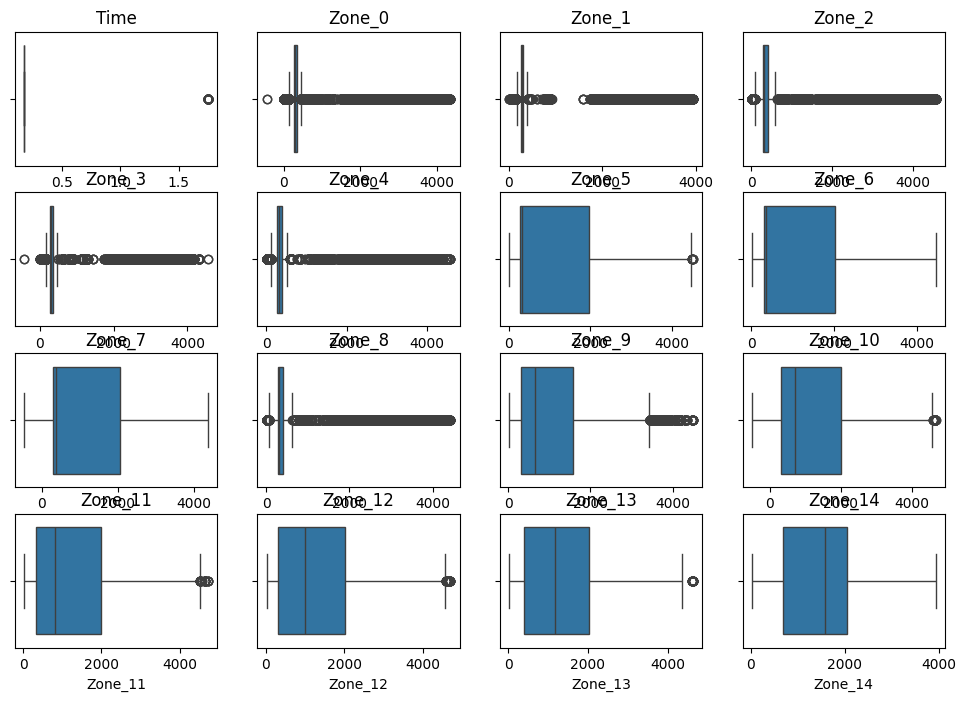

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your dataset (adjust the path and filename as needed)

data =df
# Display the first few rows of the dataset
print(data.head())

# Check for missing values
missing_values = data.isnull().sum()
print("Missing values in each column:\n", missing_values)

# Plot heatmap for missing values
plt.figure(figsize=(10, 6))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

# Plot boxplots to check for outliers
plt.figure(figsize=(12, 8))
for i, column in enumerate(data.columns, 1):
    plt.subplot(4, 4, i)  # Adjust the grid size based on number of features
    sns.boxplot(x=data[column])
    plt.title(column)
plt.tight_layout()
plt.show()

# Plot histogram and KDE for each feature
plt.figure(figsize=(12, 8))
for i, column in enumerate(data.columns, 1):
    plt.subplot(4, 4, i)  # Adjust the grid size based on number of features
    sns.histplot(data[column], kde=True, bins=30)
    plt.title(column)
plt.tight_layout()
plt.show()

# Visualize distribution of target variable
plt.figure(figsize=(8, 6))
sns.histplot(data['target'], kde=True, bins=30)  # Replace 'target' with your actual target column name
plt.title('Target Variable Distribution')
plt.xlabel('Target Value')
plt.ylabel('Frequency')
plt.show()

In [ ]:
import numpy as np, pandas as pd, tensorflow as tf, random, os
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# reproducibility
SEED = 42
tf.random.set_seed(SEED);  np.random.seed(SEED);  random.seed(SEED)

# ──────────────────────────────────────────────────────────
# 0.  TAKE THE READY ARRAYS  (X, y, pid_codes)
#     and   remove mini-sips  (<5 ml)
# ──────────────────────────────────────────────────────────
mask = y >= 5.0
X, y, pids = X[mask], y[mask], pid_codes[mask]

print(f"Total sips kept : {len(y)}")
print(f"Average sip ΔV  : {y.mean():.2f} ml")

# ──────────────────────────────────────────────────────────
# 1.  STANDARDISE SENSOR FEATURES  (global z-score)
# ──────────────────────────────────────────────────────────
n_samples, MAXLEN, NFEAT = X.shape
scaler = StandardScaler().fit(X.reshape(-1, NFEAT))
X = scaler.transform(X.reshape(-1, NFEAT)).reshape(n_samples, MAXLEN, NFEAT)

# ──────────────────────────────────────────────────────────
# 2.  DEFINE A LIGHTWEIGHT REGRESSOR
# ──────────────────────────────────────────────────────────
# def build_regressor(maxlen=MAXLEN, nfeat=NFEAT, pad_val=0.0):
#     inp = layers.Input(shape=(maxlen, nfeat))
#     x   = layers.Masking(mask_value=pad_val)(inp)
#     x   = layers.Conv1D(128, 5, padding="same")(x)
#     x   = layers.BatchNormalization()(x)
#     x   = layers.Activation("relu")(x)
#     x   = layers.Dropout(0.3)(x)
#     x   = layers.GlobalAveragePooling1D()(x)
#     out = layers.Dense(1)(x)
#     model = models.Model(inp, out)
#     model.compile(optimizer="adam",
#                   loss=tf.keras.losses.Huber(),
#                   metrics=["mae"])
#     return model
def build_regressor(maxlen=120, nfeat=64, pad_val=0.0):
    inp = layers.Input(shape=(maxlen, nfeat))
    x = layers.Masking(mask_value=pad_val)(inp)
    
    # First Convolutional Block
    x = layers.Conv1D(256, 5, padding="same")(x)  # Increased filters
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.3)(x)
    
    # Second Convolutional Block
    x = layers.Conv1D(256, 5, padding="same")(x)  # Second Conv Layer
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.3)(x)
    
    # Adding a Third Convolutional Block
    x = layers.Conv1D(256, 3, padding="same")(x)  # Smaller kernel size
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.3)(x)
    
    # Global Pooling Layer
    x = layers.GlobalAveragePooling1D()(x)
    
    # Dense Layer with Increased Neurons
    x = layers.Dense(128, activation='relu')(x)  # More units in dense layer
    x = layers.Dropout(0.3)(x)  # Additional dropout to prevent overfitting
    
    # Final Output Layer
    out = layers.Dense(1)(x)

    # Compile the model
    model = models.Model(inp, out)
    model.compile(optimizer="adam",
                  loss=tf.keras.losses.Huber(),
                  metrics=["mae"])
                  
    return model
# ──────────────────────────────────────────────────────────
# 3.  5-FOLD  GROUP  CROSS-VALIDATION
# ──────────────────────────────────────────────────────────
kf = GroupKFold(n_splits=5)
mse_l, mae_l, r2_l, rmspe_l = [], [], [], []

for fold, (tr, te) in enumerate(kf.split(X, y, groups=pids), 1):
    net = build_regressor()
    net.fit(X[tr], y[tr],
            epochs=50, batch_size=32, verbose=0,
            validation_split=0.1,
            callbacks=[tf.keras.callbacks.EarlyStopping(
                       patience=5, restore_best_weights=True)])
    
    y_hat = net.predict(X[te], verbose=0).squeeze()
    
    mse   = mean_squared_error(y[te], y_hat)
    mae   = mean_absolute_error(y[te], y_hat)
    r2    = r2_score(y[te], y_hat)
    rmspe = np.sqrt(mse) / y[te].mean()
    
    mse_l.append(mse);   mae_l.append(mae);   r2_l.append(r2);   rmspe_l.append(rmspe)
    
    print(f"fold{fold}:  RMSE={np.sqrt(mse):5.2f}  MAE={mae:5.2f}  "
          f"R²={r2:5.2f}  RMSPE={100*rmspe:5.2f}%")

# ──────────────────────────────────────────────────────────
print("\n──────────  CV AVERAGE  ──────────")
print(f"RMSE  {np.sqrt(np.mean(mse_l)):.2f}  "
      f"MAE {np.mean(mae_l):.2f}  "
      f"R²  {np.mean(r2_l):.2f}  "
      f"RMSPE {100*np.mean(rmspe_l):.2f}%")